# Model Selection & Baseline Performance

In this notebook, we aim to identify the most suitable machine learning algorithm for predicting customer churn. We will evaluate various classification models using default hyperparameters to establish a baseline performance.

**Objectives:**
1.  **Model Comparison:** Train and compare multiple algorithms.
2.  **Metric Evaluation:** Assess models based on **F1-Score** and **ROC-AUC**.
3.  **Selection:** Select the top-performing model(s) for further hyperparameter tuning in the next stage.

In [1]:
# Import necessary libraries
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb
import catboost
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler

# Add the project root directory to sys.path to allow importing from 'src'
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Import the custom preprocessor after adding path
from src.ml.preprocessor import CustomerChurnPreprocessor

In [2]:
# Load the processed training data
train_data = pd.read_csv('../data/processed/train.csv')

In [3]:
# Preprocess the data using the custom preprocessor
preprocessor = CustomerChurnPreprocessor()
train_data_processed = preprocessor.preprocess(train_data)

In [4]:
# Separate features and target variable
X_train = train_data_processed.drop('Exited', axis=1)
y_train = train_data_processed['Exited']

print(f"Training Set Size: {X_train.shape}")

Training Set Size: (9000, 20)


In [ ]:
# Benchmarking multiple models using 5-Fold Cross-Validation
def benchmark_models(X, y):
    models = {
        "K-Nearest Neighbors": make_pipeline(MinMaxScaler(), KNeighborsClassifier()),
        "Support Vector Machine": make_pipeline(MinMaxScaler(), SVC(probability=True, random_state=42)),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Gradient Boosting": GradientBoostingClassifier(random_state=42),
        "CatBoost": catboost.CatBoostClassifier(verbose=0, random_state=42),
        "XGBoost": xgb.XGBClassifier(eval_metric='logloss', random_state=42),
        "LightGBM": lgb.LGBMClassifier(verbose=-1, random_state=42),
        "Naive Bayes": GaussianNB()
    }
    
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    results = []
    print(f"\n{len(models)} Different Models are being tested on Train Set with 5-Fold CV...\n")
    print(f"{'Model Name':<25} | {'ROC-AUC Score'}")
    
    for name, model in models.items():
        cv_results = cross_val_score(model, X, y, cv=kfold, scoring='roc_auc', n_jobs=1)
        
        results.append({
            "Model": name,
            "ROC-AUC Mean": cv_results.mean(),  
            "ROC-AUC Std": cv_results.std() 
        })
        
        print(f" {name:<25} | {cv_results.mean():.4f} (+/- {cv_results.std():.4f})")
        
    df_results = pd.DataFrame(results).sort_values(by="ROC-AUC Mean", ascending=False)
    return df_results

results_df = benchmark_models(X_train, y_train)


8 Different Models are being tested on Train Set with 5-Fold CV...

Model Name                | ROC-AUC Score
 K-Nearest Neighbors       | 0.6540 (+/- 0.0108)
 Support Vector Machine    | 0.8005 (+/- 0.0150)
 Decision Tree             | 0.6834 (+/- 0.0130)
 Gradient Boosting         | 0.8656 (+/- 0.0069)
 CatBoost                  | 0.8643 (+/- 0.0092)
 XGBoost                   | 0.8396 (+/- 0.0097)
 LightGBM                  | 0.8569 (+/- 0.0066)
 Naive Bayes               | 0.7354 (+/- 0.0106)


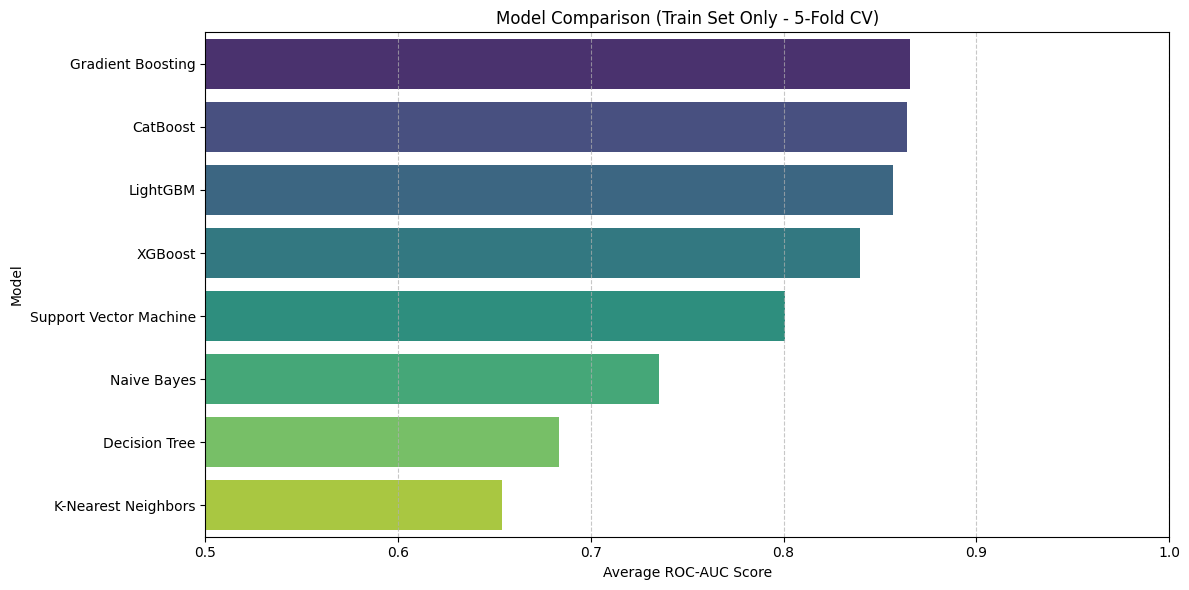

                    Model  ROC-AUC Mean  ROC-AUC Std
3       Gradient Boosting      0.865628     0.006950
4                CatBoost      0.864292     0.009236
6                LightGBM      0.856856     0.006619
5                 XGBoost      0.839642     0.009683
1  Support Vector Machine      0.800505     0.014990
7             Naive Bayes      0.735387     0.010586
2           Decision Tree      0.683375     0.012994
0     K-Nearest Neighbors      0.653957     0.010780


In [9]:
# Visualize the results
plt.figure(figsize=(12, 6))
sns.barplot(x="ROC-AUC Mean", y="Model", data=results_df, palette="viridis", hue="Model", legend=False)
plt.title("Model Comparison (Train Set Only - 5-Fold CV)")
plt.xlabel("Average ROC-AUC Score")
plt.xlim(0.5, 1.0) 
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(results_df)

In [ ]:
# Print the top 2 performing models
best_model_name = results_df.iloc[0:2]['Model']
print(f"\nTop performing models based on ROC-AUC:\n{best_model_name}")


Top performing models based on ROC-AUC:
3    Gradient Boosting
4             CatBoost
6             LightGBM
Name: Model, dtype: object
